# ECON4002 — Week 11: Welfare Economics: R Code Implementations

**University of Western Australia**  
*R implementations for consumer/producer surplus, price controls, CV and EV calculations*

---

## Key Formulae

Social welfare: $W = CS + PS - \text{externality cost}$. Pigouvian tax: $t^* = \text{MEC at optimum}$

---

> **How to use:** Run each cell in order. Modify the parameters and re-run to explore the economics.

In [ ]:
# ECON4002 Week 11 — R Setup
# Run this cell first to configure options
options(scipen = 6, digits = 4)
cat('Week 11: Welfare Economics: R Code Implementations — ready!\n')

Week 11: Welfare Economics: R Code Implementations — ready!


## Surplus

### W11-CS01 — Consumer Surplus Calculation

> **Note:** For linear inverse demand P = a - bQ. CS is triangle below demand, above price.

In [ ]:
consumer_surplus <- function(a, b, p_star, Q_star = NULL) {
  if (is.null(Q_star)) Q_star <- (a - p_star) / b
  CS <- 0.5 * (a - p_star) * Q_star
  cat('CS = ½ ×', (a - p_star), '×', Q_star, '=', CS, '\n')
  return(CS)
}

# Example: Inverse demand P = 10 - Q, price = 6
CS <- consumer_surplus(a = 10, b = 1, p_star = 6)

### W11-CS02 — Producer Surplus Calculation

> **Note:** For linear inverse supply P = c + dQ. PS is triangle above supply, below price.

In [ ]:
producer_surplus <- function(c, d, p_star, Q_star = NULL) {
  if (is.null(Q_star)) Q_star <- (p_star - c) / d
  PS <- 0.5 * (p_star - c) * Q_star
  cat('PS = ½ ×', (p_star - c), '×', Q_star, '=', PS, '\n')
  return(PS)
}

# Example: Inverse supply P = 2 + Q, price = 6
PS <- producer_surplus(c = 2, d = 1, p_star = 6)

## Equilibrium

### W11-CS03 — Market Equilibrium Welfare

> **Note:** Complete welfare analysis at competitive equilibrium.

In [ ]:
market_welfare <- function(a, b, c, d) {
  Q_star <- (a - c) / (b + d)
  p_star <- a - b * Q_star
  
  CS <- 0.5 * (a - p_star) * Q_star
  PS <- 0.5 * (p_star - c) * Q_star
  W <- CS + PS
  
  cat('Equilibrium: p* =', round(p_star, 2), ', Q* =', round(Q_star, 2), '\n')
  cat('CS =', round(CS, 2), ', PS =', round(PS, 2), ', W =', round(W, 2), '\n')
  
  list(p = p_star, Q = Q_star, CS = CS, PS = PS, W = W)
}

eq <- market_welfare(a = 7, b = 1, c = 1, d = 1)

## Visualization

### W11-CS04 — Plot CS and PS

> **Note:** Visualizes CS (blue) and PS (red) as shaded areas.

In [ ]:
plot_welfare <- function(a, b, c, d) {
  eq <- market_welfare(a, b, c, d)
  Q_range <- seq(0, eq$Q * 1.5, length = 200)
  P_d <- a - b * Q_range; P_s <- c + d * Q_range
  
  plot(Q_range, P_d, type='l', col='blue', lwd=2,
       ylim=c(0, a*1.1), xlab='Q', ylab='P', main='Welfare')
  lines(Q_range, P_s, col='red', lwd=2)
  
  Q_cs <- seq(0, eq$Q, length=100)
  polygon(c(Q_cs, rev(Q_cs)), c(a - b*Q_cs, rep(eq$p, 100)),
          col=rgb(0,0,1,0.3), border=NA)
  polygon(c(Q_cs, rev(Q_cs)), c(rep(eq$p, 100), rev(c + d*Q_cs)),
          col=rgb(1,0,0,0.3), border=NA)
  
  points(eq$Q, eq$p, pch=19, cex=1.5)
  legend('topright', c('D','S','CS','PS'),
         col=c('blue','red',rgb(0,0,1,0.3),rgb(1,0,0,0.3)),
         lwd=c(2,2,NA,NA), pch=c(NA,NA,15,15))
  grid()
}

plot_welfare(7, 1, 1, 1)

## Price Controls

### W11-CS05 — Price Ceiling Analysis

> **Note:** Analyzes welfare effects of binding price ceiling. Returns shortage and DWL.

In [ ]:
price_ceiling <- function(a, b, c, d, p_ceil) {
  eq <- market_welfare(a, b, c, d)
  if (p_ceil >= eq$p) { cat('Ceiling not binding\n'); return(NULL) }
  
  Q_d <- (a - p_ceil)/b; Q_s <- (p_ceil - c)/d
  Q_traded <- min(Q_d, Q_s)
  
  P_d_at_Q <- a - b * Q_traded
  CS_new <- 0.5*(a - P_d_at_Q)*Q_traded + (P_d_at_Q - p_ceil)*Q_traded
  PS_new <- 0.5*(p_ceil - c)*Q_traded
  DWL <- eq$W - (CS_new + PS_new)
  
  cat('=== Price Ceiling (p^c =', p_ceil, ') ===\n')
  cat('Q_traded:', round(Q_traded,2), ', Shortage:', round(Q_d-Q_s,2), '\n')
  cat('CS:', round(CS_new,2), ', PS:', round(PS_new,2), '\n')
  cat('DWL:', round(DWL,2), '\n')
  
  list(Q=Q_traded, shortage=Q_d-Q_s, CS=CS_new, PS=PS_new, DWL=DWL)
}

price_ceiling(7, 1, 1, 1, p_ceil = 2)

### W11-CS06 — Price Floor Analysis

> **Note:** Analyzes price floor. Includes government purchase cost if surplus is bought.

In [ ]:
price_floor <- function(a, b, c, d, p_floor) {
  eq <- market_welfare(a, b, c, d)
  if (p_floor <= eq$p) { cat('Floor not binding\n'); return(NULL) }
  
  Q_d <- (a - p_floor)/b; Q_s <- (p_floor - c)/d
  Q_traded <- Q_d  # Demand is short side
  surplus <- Q_s - Q_d
  
  CS_new <- 0.5*(a - p_floor)*Q_traded
  PS_new <- 0.5*(p_floor - c)*Q_traded
  DWL <- eq$W - (CS_new + PS_new)
  gov_cost <- p_floor * surplus
  
  cat('=== Price Floor (p^f =', p_floor, ') ===\n')
  cat('Q_traded:', round(Q_traded,2), ', Surplus:', round(surplus,2), '\n')
  cat('Govt purchase cost:', round(gov_cost,2), '\n')
  cat('DWL:', round(DWL,2), '\n')
  
  list(Q=Q_traded, surplus=surplus, gov_cost=gov_cost, DWL=DWL)
}

price_floor(7, 1, 1, 1, p_floor = 5)

### W11-CS07 — Visualize Price Ceiling

> **Note:** Shows DWL triangle from price ceiling.

In [ ]:
plot_ceiling <- function(a, b, c, d, p_ceil) {
  eq <- market_welfare(a, b, c, d)
  Q_max <- max(eq$Q, (a-p_ceil)/b)*1.3
  Q_range <- seq(0, Q_max, length=200)
  
  plot(Q_range, a-b*Q_range, type='l', col='blue', lwd=2,
       ylim=c(0,a*1.1), xlab='Q', ylab='P', main=paste('Ceiling p=',p_ceil))
  lines(Q_range, c+d*Q_range, col='red', lwd=2)
  abline(h=p_ceil, col='darkgreen', lwd=2, lty=2)
  
  Q_s <- (p_ceil-c)/d
  polygon(c(Q_s, eq$Q, Q_s), c(p_ceil, eq$p, a-b*Q_s),
          col=rgb(1,1,0,0.5), border='orange', lwd=2)
  
  legend('topright', c('D','S','Ceiling','DWL'),
         col=c('blue','red','darkgreen',rgb(1,1,0,0.5)),
         lwd=c(2,2,2,NA), pch=c(NA,NA,NA,15))
  grid()
}

plot_ceiling(7, 1, 1, 1, p_ceil = 2)

## Cv Ev

### W11-CS08 — CV and EV for Cobb-Douglas

> **Note:** Calculates CV, EV, and ΔCS for Cobb-Douglas. For price decrease: |CV| < ΔCS < EV.

In [ ]:
cv_ev_cd <- function(p1_old, p1_new, p2, m, alpha = 0.5) {
  # Optimal bundles
  x1_old <- alpha*m/p1_old; x2_old <- (1-alpha)*m/p2
  x1_new <- alpha*m/p1_new; x2_new <- (1-alpha)*m/p2
  
  # Utility levels
  u_old <- x1_old^alpha * x2_old^(1-alpha)
  u_new <- x1_new^alpha * x2_new^(1-alpha)
  
  # Expenditure function: e = (u/k) * p1^α * p2^(1-α)
  k <- alpha^alpha * (1-alpha)^(1-alpha)
  e_fn <- function(p1, p2, u) (u/k) * p1^alpha * p2^(1-alpha)
  
  CV <- e_fn(p1_new, p2, u_old) - m
  EV <- e_fn(p1_old, p2, u_new) - m
  CS <- alpha * m * log(p1_old / p1_new)
  
  cat('=== CV and EV ===\n')
  cat('u_old:', round(u_old,2), ', u_new:', round(u_new,2), '\n')
  cat('CV:', round(CV,2), ', ΔCS:', round(CS,2), ', EV:', round(EV,2), '\n')
  
  list(CV=CV, EV=EV, CS=CS)
}

cv_ev_cd(10, 5, 5, 100, 0.5)

### W11-CS09 — CV and EV for U = x₁x₂

> **Note:** For multiplicative utility U = x₁x₂. Used in lecture example.

In [ ]:
cv_ev_product <- function(p1_old, p1_new, p2, m) {
  # For U = x1*x2, demands are x1 = m/(2p1), x2 = m/(2p2)
  x1_old <- m/(2*p1_old); x2_old <- m/(2*p2)
  x1_new <- m/(2*p1_new); x2_new <- m/(2*p2)
  
  u_old <- x1_old * x2_old
  u_new <- x1_new * x2_new
  
  # Expenditure: e(p1,p2,u) = 2*sqrt(u*p1*p2)
  e_fn <- function(p1, p2, u) 2*sqrt(u*p1*p2)
  
  CV <- e_fn(p1_new, p2, u_old) - m
  EV <- e_fn(p1_old, p2, u_new) - m
  
  cat('Old bundle: (', x1_old, ',', x2_old, '), U =', u_old, '\n')
  cat('New bundle: (', x1_new, ',', x2_new, '), U =', u_new, '\n')
  cat('CV =', round(CV, 2), '\n')
  cat('EV =', round(EV, 2), '\n')
  
  list(CV=CV, EV=EV, u_old=u_old, u_new=u_new)
}

cv_ev_product(10, 5, 5, 100)

### W11-CS10 — Visualize CV and EV

> **Note:** Shows indifference curves and budget lines for CV/EV analysis.

In [ ]:
plot_cv_ev <- function(p1_old, p1_new, p2, m, alpha = 0.5) {
  x1_old <- alpha*m/p1_old; x2_old <- (1-alpha)*m/p2
  x1_new <- alpha*m/p1_new; x2_new <- (1-alpha)*m/p2
  
  u_old <- x1_old^alpha * x2_old^(1-alpha)
  u_new <- x1_new^alpha * x2_new^(1-alpha)
  
  x1_max <- max(x1_old, x1_new)*1.5
  x1_range <- seq(0.1, x1_max, length=200)
  
  IC_old <- (u_old/x1_range^alpha)^(1/(1-alpha))
  IC_new <- (u_new/x1_range^alpha)^(1/(1-alpha))
  BL_old <- (m - p1_old*x1_range)/p2
  BL_new <- (m - p1_new*x1_range)/p2
  
  plot(x1_range, IC_old, type='l', col='blue', lwd=2,
       xlim=c(0,x1_max), ylim=c(0,max(x2_old,x2_new)*1.5),
       xlab=expression(x[1]), ylab=expression(x[2]), main='CV vs EV')
  lines(x1_range, IC_new, col='red', lwd=2)
  lines(x1_range, pmax(0,BL_old), col='blue', lty=2)
  lines(x1_range, pmax(0,BL_new), col='red', lty=2)
  
  points(x1_old, x2_old, pch=19, cex=1.5, col='blue')
  points(x1_new, x2_new, pch=19, cex=1.5, col='red')
  legend('topright', c('IC(u⁰)','IC(u¹)','BL old','BL new'),
         col=c('blue','red','blue','red'), lwd=2, lty=c(1,1,2,2))
  grid()
}

plot_cv_ev(10, 5, 5, 100, 0.5)

## Discrete

### W11-CS11 — Welfare from Discrete Data

> **Note:** For discrete WTP/WTA data. Sums surplus for each unit.

In [ ]:
welfare_discrete <- function(wtp, wta, price) {
  # wtp: consumer willingness to pay per unit
  # wta: producer min acceptable price per unit
  
  units_bought <- sum(wtp >= price)
  CS <- sum(pmax(0, wtp - price))
  
  units_sold <- sum(wta <= price)
  PS <- sum(pmax(0, price - wta))
  
  cat('Price:', price, '\n')
  cat('Units traded:', min(units_bought, units_sold), '\n')
  cat('CS:', CS, ', PS:', PS, ', W:', CS+PS, '\n')
  
  list(CS=CS, PS=PS, W=CS+PS)
}

# Example from lecture table
wtp <- c(50, 40, 30, 20, 10)
wta <- c(8, 12, 16, 20, 24)
welfare_discrete(wtp, wta, price = 25)

## Complete

### W11-CS12 — Complete Welfare Toolkit

> **Note:** Unified interface for all welfare calculations on a given market.

In [ ]:
welfare_toolkit <- function(a, b, c, d) {
  list(
    equilibrium = function() market_welfare(a, b, c, d),
    ceiling = function(p) price_ceiling(a, b, c, d, p),
    floor = function(p) price_floor(a, b, c, d, p),
    plot = function() plot_welfare(a, b, c, d),
    plot_ceiling = function(p) plot_ceiling(a, b, c, d, p)
  )
}

# Usage
mkt <- welfare_toolkit(10, 1, 2, 1)
mkt$equilibrium()
mkt$ceiling(4)
mkt$plot()

## Viewer Test: HTML Table Output

The cell below has a pre-rendered HTML table (simulating a data frame `print()`). This tests the notebook viewer's HTML output rendering.

In [ ]:
# Data frame display — output pre-rendered for viewer testing
farm_data <- data.frame(
  crop    = c('wheat', 'corn', 'soybean'),
  yield   = c(45, 180, 50),
  price   = c(7.50, 4.50, 13.00),
  revenue = c(337.50, 810.00, 650.00)
)
farm_data

,crop,yield,price,revenue
0,wheat,45,7.50,337.50
1,corn,180,4.50,810.00
2,soybean,50,13.00,650.00


## Viewer Test: Image Output

The cell below has a pre-rendered supply & demand plot. This tests the notebook viewer's image rendering.

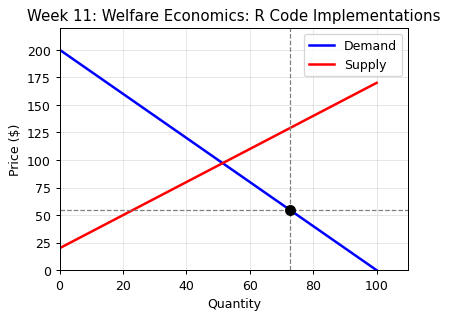

In [ ]:
# Supply & demand plot — output pre-rendered for viewer testing
P_range <- seq(0, 100, by = 0.5)
Qd <- 200 - 2 * P_range
Qs <- 20 + 1.5 * P_range
plot(Qd, P_range, type='l', col='blue', lwd=2,
     xlab='Quantity', ylab='Price', main='Supply & Demand')
lines(Qs, P_range, col='red', lwd=2)
legend('topright', c('Demand','Supply'), col=c('blue','red'), lty=1)

## Viewer Test: Empty Cell

The cell below is intentionally empty — the viewer should skip it gracefully.

## Common Patterns

**Consumer Surplus**

```r
# For inverse demand P = a - bQ
CS <- 0.5 * (a - p_star) * Q_star
```

**CV for Cobb-Douglas**

```r
# CV = e(p_new, u_old) - m
# e(p1,p2,u) = (u/k) * p1^α * p2^(1-α)
# k = α^α * (1-α)^(1-α)
```

**DWL from Ceiling**

```r
# DWL = W_free - W_ceiling
# W_ceiling = CS_ceiling + PS_ceiling
```

## Debugging Tips

| Error | Cause | Fix |
|-------|-------|-----|
| `Negative consumer surplus` | Price above demand intercept | Check that p_star < a (demand intercept) |
| `Price control not binding` | Ceiling above or floor below equilibrium | Check that p_ceil < p* or p_floor > p* |
| `CV and EV have unexpected signs` | Sign convention varies by price direction | For price decrease: CV < 0 (would pay), EV > 0 (income equivalent) |